# Aprendizado Supervisionado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    r2_score,
)

In [2]:
from pathlib import Path
pasta_dados = Path("data")
pasta_dados.mkdir(exist_ok=True)

df_noticias = pd.read_csv(pasta_dados / "noticias.csv")
df_bow = pd.read_csv(pasta_dados/"bow.csv")
df_tfidf = pd.read_csv(pasta_dados/"tfidf.csv")

df_tfidf.head(2)

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,tfidf_votacao,tfidf_vulnerabilidade,tfidf_vulneraveis,tfidf_willian,tfidf_xadrez,tfidf_xxvii,tfidf_yago,tfidf_youtube,tfidf_zema,tfidf_zona
0,Minas promove capacitação de clubes de futebol...,Fale Agora será apresentado em times femininos...,Em continuidade à propagação e divulgação do P...,"['Social', 'Esportes']",2024-04-27 12:20:00-03:00,2024-04,2024,4,12,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,"Competição acontece em Uberlândia, no Triângul...",A delegação de Minas Gerais encerrou o primeir...,"['Social', 'Esportes']",2025-10-14 15:20:00-03:00,2025-10,2025,10,15,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_tfidf.columns.tolist()

['titulo',
 'subtitulo',
 'descricao',
 'temas',
 'data',
 'ano_mes',
 'ano',
 'mes',
 'hora',
 'turno',
 'n_temas',
 'tamanho_texto',
 'n_palavras_titulo',
 'n_relacionadas',
 'url',
 'tfidf_abastecimento',
 'tfidf_aberta',
 'tfidf_abertas',
 'tfidf_aberto',
 'tfidf_abertura',
 'tfidf_abrangendo',
 'tfidf_abre',
 'tfidf_abriu',
 'tfidf_acaba',
 'tfidf_acao',
 'tfidf_acende',
 'tfidf_acervo',
 'tfidf_acesso',
 'tfidf_achava',
 'tfidf_acidente',
 'tfidf_acirradas',
 'tfidf_aco',
 'tfidf_acoes',
 'tfidf_acompanhar',
 'tfidf_acompanhou',
 'tfidf_acontecera',
 'tfidf_acordo',
 'tfidf_administrado',
 'tfidf_administrativa',
 'tfidf_adolescentes',
 'tfidf_adorava',
 'tfidf_aeroporto',
 'tfidf_agencia',
 'tfidf_agora',
 'tfidf_agosto',
 'tfidf_agraciados',
 'tfidf_aguardada',
 'tfidf_aguiar',
 'tfidf_ai',
 'tfidf_ainda',
 'tfidf_ajuda',
 'tfidf_ajudando',
 'tfidf_alba',
 'tfidf_alcancar',
 'tfidf_alcancaram',
 'tfidf_alcancou',
 'tfidf_alegria',
 'tfidf_alem',
 'tfidf_alencar',
 'tfidf_alguma

## montando a matriz de features X

Pegamos so as colunas que comecam com `tfidf_` para formar a matriz `X`.

In [4]:
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]
X = df_tfidf[colunas_tfidf].values
print("X:", X.shape)

X: (323, 1313)


## Classificação - A notícia menciona Belo Horizonte?

Modelo construido visando identificar notícias que mencionam Belo Horizonte e, consequentemente,  avaliar se as notícias de esporte do site agência de Minas são centradas e monopolizadas na capital.

In [5]:
df_tfidf.columns

Index(['titulo', 'subtitulo', 'descricao', 'temas', 'data', 'ano_mes', 'ano',
       'mes', 'hora', 'turno',
       ...
       'tfidf_votacao', 'tfidf_vulnerabilidade', 'tfidf_vulneraveis',
       'tfidf_willian', 'tfidf_xadrez', 'tfidf_xxvii', 'tfidf_yago',
       'tfidf_youtube', 'tfidf_zema', 'tfidf_zona'],
      dtype='object', length=1328)

In [6]:
texto = df_tfidf["descricao"].fillna("") + " " + df_tfidf["titulo"].fillna("")
y_bh = texto.str.contains(r"Belo Horizonte|\bBH\b|capital", case=False, regex=True).astype(int).values

print("Distribuicao das classes:")
vc = pd.Series(y_bh).value_counts()
print(vc.rename({0: "nao menciona BH", 1: "menciona BH"}))
print(f"\n{vc[1] / len(y_bh):.1%} das noticias mencionam Belo Horizonte")

Distribuicao das classes:
nao menciona BH    303
menciona BH         20
Name: count, dtype: int64

6.2% das noticias mencionam Belo Horizonte


### separação em treino / validação / teste

In [7]:
X_tmp, X_teste_bh, y_tmp, y_teste_bh = train_test_split(
    X, y_bh, test_size=0.2, random_state=42, stratify=y_bh
)
X_treino_bh, X_calib_bh, y_treino_bh, y_calib_bh = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_bh.shape}")
print(f"calibracao: {X_calib_bh.shape}")
print(f"teste:      {X_teste_bh.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo

In [8]:
modelo_bh = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_bh.fit(X_treino_bh, y_treino_bh)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### calibração

In [9]:
probs_calib_bh = modelo_bh.predict_proba(X_calib_bh)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_bh = []
for t in limiares:
    pred = (probs_calib_bh > t).astype(int)
    f1 = f1_score(y_calib_bh, pred, zero_division=0)
    resultados_bh.append((t, f1))

df_lim_bh = pd.DataFrame(resultados_bh, columns=["limiar", "f1_calib"])
melhor_limiar_bh = df_lim_bh.loc[df_lim_bh["f1_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_bh:.2f}")
df_lim_bh

Melhor limiar pela calibracao: 0.15


,limiar,f1_calib
0,0.10,0.666667
1,0.15,0.857143
2,0.20,0.857143
3,0.25,0.857143
4,0.30,0.857143
5,0.35,0.857143
6,0.40,0.666667
7,0.45,0.400000
8,0.50,0.400000
9,0.55,0.400000


### avaliando no teste

In [10]:
probs_teste_bh = modelo_bh.predict_proba(X_teste_bh)[:, 1]
pred_teste_bh = (probs_teste_bh > melhor_limiar_bh).astype(int)

acc  = accuracy_score(y_teste_bh, pred_teste_bh)
prec = precision_score(y_teste_bh, pred_teste_bh, zero_division=0)
rec  = recall_score(y_teste_bh, pred_teste_bh, zero_division=0)
f1   = f1_score(y_teste_bh, pred_teste_bh, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_bh, pred_teste_bh, target_names=["nao menciona BH", "menciona BH"]))

Acuracia: 1.000
Precisao: 1.000
Recall:   1.000
F1:       1.000

Relatorio completo:
                 precision    recall  f1-score   support

nao menciona BH       1.00      1.00      1.00        61
    menciona BH       1.00      1.00      1.00         4

       accuracy                           1.00        65
      macro avg       1.00      1.00      1.00        65
   weighted avg       1.00      1.00      1.00        65



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
                 nao menciona BH  menciona BH
nao menciona BH               61            0
menciona BH                    0            4


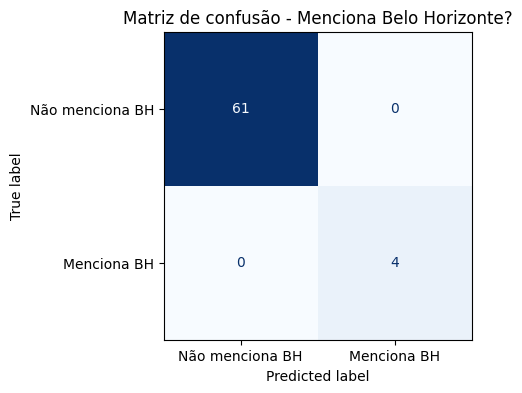

In [11]:
cm_bh = confusion_matrix(y_teste_bh, pred_teste_bh)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_bh, index=["nao menciona BH", "menciona BH"], columns=["nao menciona BH", "menciona BH"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_bh, display_labels=["Não menciona BH", "Menciona BH"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusão - Menciona Belo Horizonte?")
plt.show()

## 2) Classificação - A notícia tem a tag Social?

A coluna `temas` contem as tags associadas a cada notícia. Esse modelo visa identificar as notícias de esporte que apresentam cunho social (inclusão, programas sociais, vulnerabilidade, entre outros.

In [12]:
y_infra = df_tfidf["temas"].str.contains("Infraestrutura", na=False).astype(int).values

print("Distribuicao das classes:")
print(pd.Series(y_infra).value_counts().rename({0: "sem infraestrutura", 1: "com infraestrutura"}))

Distribuicao das classes:
sem infraestrutura    288
com infraestrutura     35
Name: count, dtype: int64


### separação em treino / validação / teste

In [13]:
X_tmp, X_teste_infra, y_tmp, y_teste_infra = train_test_split(
    X, y_infra, test_size=0.2, random_state=42, stratify=y_infra
)
X_treino_infra, X_calib_infra, y_treino_infra, y_calib_infra = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_infra.shape}")
print(f"calibracao: {X_calib_infra.shape}")
print(f"teste:      {X_teste_infra.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo

In [14]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
modelo_svm.fit(X_treino_infra, y_treino_infra)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


### calibração

In [15]:
probs_calib_svm = modelo_svm.predict_proba(X_calib_infra)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_svm = []
for t in limiares:
    pred = (probs_calib_svm > t).astype(int)
    acc = accuracy_score(y_calib_infra, pred)
    resultados_svm.append((t, acc))

df_lim_svm = pd.DataFrame(resultados_svm, columns=["limiar", "acuracia_calib"])
melhor_limiar_svm = df_lim_svm.loc[df_lim_svm["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_svm:.2f}")
df_lim_svm

Melhor limiar pela calibracao: 0.15


,limiar,acuracia_calib
0,0.10,0.876923
1,0.15,0.953846
2,0.20,0.938462
3,0.25,0.923077
4,0.30,0.938462
5,0.35,0.923077
6,0.40,0.907692
7,0.45,0.907692
8,0.50,0.907692
9,0.55,0.907692


### avaliando no teste

In [16]:
probs_teste_svm = modelo_svm.predict_proba(X_teste_infra)[:, 1]
pred_teste_svm = (probs_teste_svm > melhor_limiar_svm).astype(int)

acc  = accuracy_score(y_teste_infra, pred_teste_svm)
prec = precision_score(y_teste_infra, pred_teste_svm, zero_division=0)
rec  = recall_score(y_teste_infra, pred_teste_svm, zero_division=0)
f1   = f1_score(y_teste_infra, pred_teste_svm, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_infra, pred_teste_svm, target_names=["não é de infraestrutura", "é de infraestrutura"]))

Acuracia: 0.923
Precisao: 0.667
Recall:   0.571
F1:       0.615

Relatorio completo:
                         precision    recall  f1-score   support

não é de infraestrutura       0.95      0.97      0.96        58
    é de infraestrutura       0.67      0.57      0.62         7

               accuracy                           0.92        65
              macro avg       0.81      0.77      0.79        65
           weighted avg       0.92      0.92      0.92        65



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
                         não é de infraestrutura  é de infraestrutura
não é de infraestrutura                       56                    2
é de infraestrutura                            3                    4


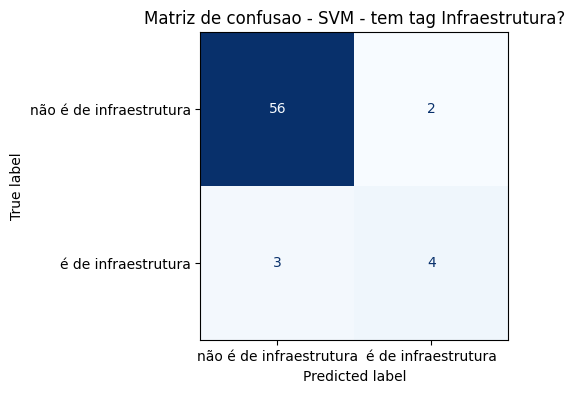

In [17]:
cm_svm = confusion_matrix(y_teste_infra, pred_teste_svm)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_svm, index=["não é de infraestrutura", "é de infraestrutura"], columns=["não é de infraestrutura", "é de infraestrutura"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_svm, display_labels=["não é de infraestrutura", "é de infraestrutura"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - SVM - tem tag Infraestrutura?")
plt.show()

## 3) Regressão - Prever o numero de temas da notícia.

O vocabulário do texto consegue prever o quão ampla é a cobertura editoral da notícia? Ou seja, a partir do texto da notícia, conseguimos prever a dimensão de temas que ela engloba?

In [18]:
y_reg = df_tfidf["n_temas"].values

print("Estatisticas do alvo:")
print(pd.Series(y_reg).describe())

Estatisticas do alvo:
count    323.000000
mean       2.346749
std        0.970311
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        6.000000
dtype: float64


### separação em treino / validação / teste

In [19]:
X_tmp, X_teste_r, y_tmp, y_teste_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_treino_r, X_calib_r, y_treino_r, y_calib_r = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42
)

print(f"treino:     {X_treino_r.shape}")
print(f"calibracao: {X_calib_r.shape}")
print(f"teste:      {X_teste_r.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo e escolhendo o número de árvores.

In [20]:
n_estimators_list = [10, 15, 20, 25, 30, 50, 70, 100, 120, 150, 180, 200, 220, 250, 280, 300, 350, 400, 450, 500]
resultados_reg = []
modelos_reg = {}

for n in n_estimators_list:
    modelo = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_r, y_treino_r)
    pred_calib = modelo.predict(X_calib_r)
    mae = mean_absolute_error(y_calib_r, pred_calib)
    resultados_reg.append((n, mae))
    modelos_reg[n] = modelo

df_reg = pd.DataFrame(resultados_reg, columns=["n_estimators", "MAE_calib"])
melhor_n = int(df_reg.loc[df_reg["MAE_calib"].idxmin(), "n_estimators"])
print(f"Melhor n_estimators pela calibracao: {melhor_n}")
df_reg

Melhor n_estimators pela calibracao: 15


,n_estimators,MAE_calib
0,10,0.661795
1,15,0.614530
2,20,0.618205
3,25,0.623179
4,30,0.619829
5,50,0.627056
6,70,0.623139
7,100,0.623136
8,120,0.626481
9,150,0.622826


### avaliando no teste

In [21]:
modelo_final = modelos_reg[melhor_n]
pred_teste_r = modelo_final.predict(X_teste_r)

print(f"MAE no teste: {mean_absolute_error(y_teste_r, pred_teste_r):.2f}")
print(f"R\u00b2  no teste: {r2_score(y_teste_r, pred_teste_r):.3f}")

df_comp = pd.DataFrame({
    "real": y_teste_r,
    "previsto": pred_teste_r.round(1),
}).head(10)
df_comp

MAE no teste: 0.61
R²  no teste: 0.208


,real,previsto
0,2,2.4
1,2,2.1
2,2,2.3
3,1,2.1
4,2,2.0
5,2,2.1
6,2,2.1
7,2,2.2
8,2,1.8
9,2,1.9
